# Differential expression between conditions

This tutorial shows how to find genes whose expression changes between **conditions**,
e.g. treated vs. control or disease vs. healthy, within each cell type.

This is a different question from finding **marker genes** that distinguish clusters
({mod}`scanpy.tl.markers`, see {doc}`clustering`).
Marker tests compare cells, treating every cell as an independent observation.
That is fine to rank genes, but cells from the same sample are not independent,
so for comparing conditions such tests report many false positives {cite:p}`Squair2021,Zimmerman2021`.

The established approach is **pseudobulk**: sum the counts of each cell type per sample,
then test with a method developed for bulk RNA-seq,
such as DESeq2 {cite:p}`Love2014` or edgeR {cite:p}`Robinson2010`.
Pseudobulk methods performed well in comparisons of single-cell differential expression methods
{cite:p}`Soneson2018,Crowell2020,Squair2021`.
{func}`scanpy.tl.de.deseq2` does both steps, using PyDESeq2 {cite:p}`Muzellec2023`.
It requires `pydeseq2`: `pip install 'scanpy[pydeseq2]'`.

In [1]:
from __future__ import annotations

import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch

import scanpy as sc

sc.set_figure_params(dpi=80, facecolor="white")

## Data

We use peripheral blood mononuclear cells (PBMCs) from 8 lupus patients {cite:p}`KangHM2018`.
Each patient’s cells were split in two: one half was stimulated with interferon-β (`stim`),
the other was left untreated (`ctrl`).

In [2]:
path = pooch.retrieve(
    "https://exampledata.scverse.org/pertpy/kang_2018.h5ad",
    known_hash="sha256:e6a5adac64dcdeb36eaba27db49b63e0c64bb0ed4a64c6705971506b41c39830",
)
adata = ad.io.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'
    layers: None (.X)

`adata.X` holds raw counts.
Every patient (`replicate`) contributes cells to both conditions (`label`).
The patients, not the cells, are our replicates:

In [3]:
pd.crosstab(adata.obs["replicate"], adata.obs["label"])

label,ctrl,stim
replicate,,
patient_101,858,1166
patient_107,517,525
patient_1015,2738,2352
patient_1016,1723,1635
patient_1039,461,641
patient_1244,1879,1464
patient_1256,2108,2026
patient_1488,2031,2549


To keep this tutorial fast, we focus on three cell types and on genes detected in at least 100 cells.

In [4]:
adata = adata[
    adata.obs["cell_type"].isin(["CD14+ Monocytes", "B cells", "CD4 T cells"])
].copy()
sc.pp.filter_genes(adata, min_cells=100)
adata

AnnData object with n_obs × n_vars = 19586 × 8469
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name', 'n_cells'
    obsm: 'X_pca', 'X_umap'
    layers: None (.X)

## Pseudobulk differential expression

{func}`~scanpy.tl.de.deseq2` sums the counts of every combination of `sample_key`, `condition` and `groupby`
with {func}`scanpy.get.aggregate`.
This is what the pseudobulk samples look like:

In [5]:
pseudobulk = sc.get.aggregate(adata, by=["replicate", "label", "cell_type"], func="sum")
pseudobulk.obs.head()

,replicate,label,cell_type,n_obs_aggregated
patient_101_ctrl_CD4 T cells,patient_101,ctrl,CD4 T cells,353
patient_101_ctrl_CD14+ Monocytes,patient_101,ctrl,CD14+ Monocytes,207
patient_101_ctrl_B cells,patient_101,ctrl,B cells,106
patient_101_stim_CD4 T cells,patient_101,stim,CD4 T cells,467
patient_101_stim_CD14+ Monocytes,patient_101,stim,CD14+ Monocytes,269


It then tests every level of `condition` against the `reference`, separately per `groupby` group.

Since every patient was measured in both conditions, we also pass the patient as a covariate.
This makes it a *paired* comparison: each patient’s stimulated cells are compared to the same patient’s control cells,
so differences between patients do not count as noise.

PyDESeq2 sometimes reports that its parametric dispersion trend did not converge and falls back to a mean-based trend.
This is expected for some datasets, so we silence that warning here.

In [6]:
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message="The dispersion trend curve fitting did not converge"
    )
    results = sc.tl.de.deseq2(
        adata,
        "label",
        reference="ctrl",
        sample_key="replicate",
        groupby="cell_type",
        covariates=["replicate"],
    )
results.head()

,group,condition,reference,gene,base_mean,log_fc,log_fc_se,statistic,p_value,adj_p_value
0,CD4 T cells,stim,ctrl,NOC2L,48.635394,0.045263,0.127480,0.355062,7.225432e-01,8.936082e-01
1,CD4 T cells,stim,ctrl,HES4,17.964459,1.780774,0.262175,6.792299,1.103609e-11,3.283742e-10
2,CD4 T cells,stim,ctrl,ISG15,2279.607657,5.065239,0.238060,21.277196,1.846594e-100,5.555511e-98
3,CD4 T cells,stim,ctrl,TNFRSF18,29.668643,-0.245511,0.174780,-1.404690,1.601136e-01,4.218170e-01
4,CD4 T cells,stim,ctrl,TNFRSF4,59.666281,0.315357,0.136213,2.315170,2.060364e-02,1.035000e-01


The result has one row per cell type (`group`), tested condition and gene.
Besides the log2 fold change (`log_fc`) it reports its standard error (`log_fc_se`),
and p-values adjusted for multiple testing per cell type (`adj_p_value`).

Many genes respond to interferon-β in each cell type:

In [7]:
significant = results[(results["adj_p_value"] < 0.05) & (results["log_fc"].abs() > 1)]
significant.groupby("group", observed=True).size()

group
B cells             523
CD14+ Monocytes    2023
CD4 T cells         482
dtype: int64

In [8]:
(
    significant
    .sort_values("adj_p_value")
    .groupby("group", observed=True)
    .head(5)[["group", "gene", "log_fc", "adj_p_value"]]
)

,group,gene,log_fc,adj_p_value
6304,CD4 T cells,ISG20,3.080682,0.000000e+00
23242,B cells,ISG20,3.336706,8.990021e-205
1852,CD4 T cells,TNFSF10,4.404219,1.811425e-204
162,CD4 T cells,IFI6,5.677008,1.748187e-198
7802,CD4 T cells,BST2,2.445664,5.839662e-182
2783,CD4 T cells,PSMB9,1.711618,1.700854e-180
15613,CD14+ Monocytes,H3F3B,1.150238,4.572207e-159
16940,B cells,ISG15,5.601317,1.306669e-148
11521,CD14+ Monocytes,DYNLT1,2.731112,2.025750e-128
9568,CD14+ Monocytes,TMSB10,2.245614,8.513918e-127


Among the strongest changes are interferon-stimulated genes such as *ISG15*, *ISG20*, *IFI6* and *IRF7*.

### Volcano plot

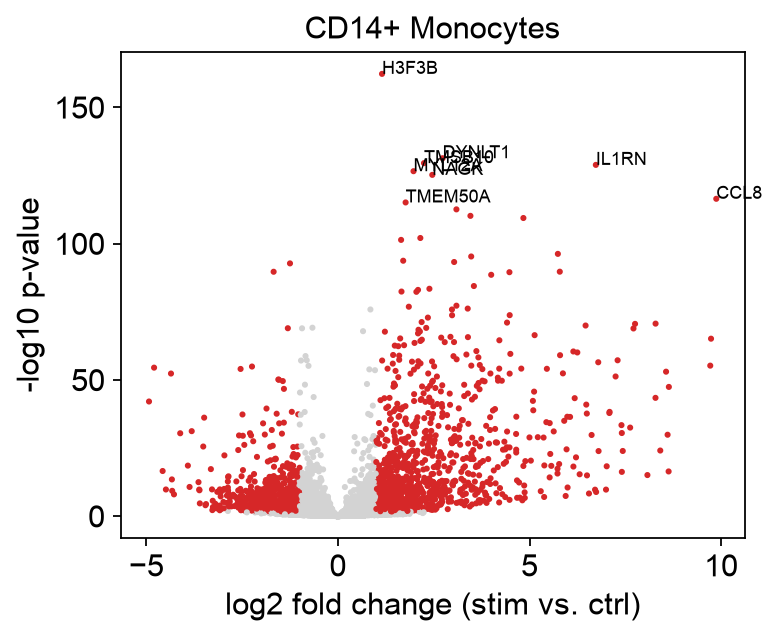

In [9]:
mono = results[results["group"] == "CD14+ Monocytes"].dropna(subset="p_value")
hit = (mono["adj_p_value"] < 0.05) & (mono["log_fc"].abs() > 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(
    mono["log_fc"],
    -np.log10(mono["p_value"]),
    s=3,
    c=np.where(hit, "tab:red", "lightgrey"),
)
for _, row in mono[hit].nsmallest(8, "p_value").iterrows():
    ax.annotate(row["gene"], (row["log_fc"], -np.log10(row["p_value"])), fontsize=8)
ax.set(
    xlabel="log2 fold change (stim vs. ctrl)",
    ylabel="-log10 p-value",
    title="CD14+ Monocytes",
)
ax.grid(visible=False)
plt.show()

### Expression of the top genes

The test uses counts. To plot expression, we normalize and log-transform a copy:

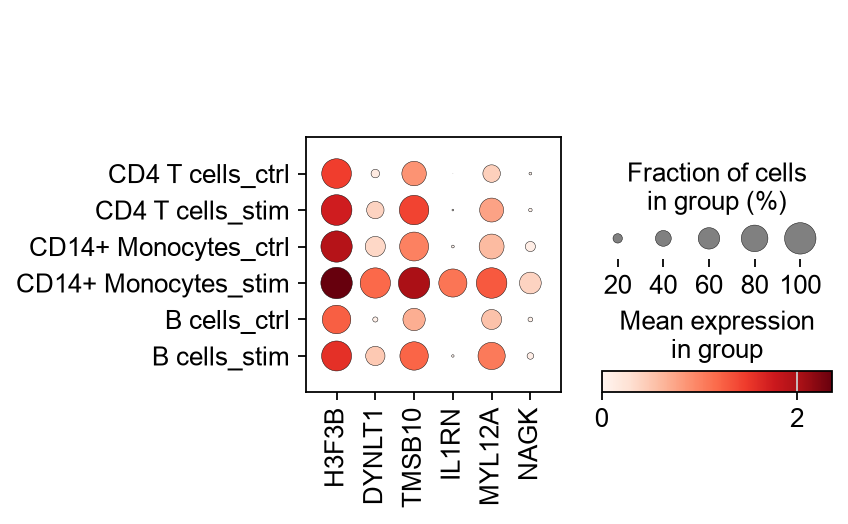

In [10]:
lognorm = adata.copy()
sc.pp.normalize_total(lognorm)
sc.pp.log1p(lognorm)

top_genes = mono.nsmallest(6, "p_value")["gene"].tolist()
sc.pl.dotplot(lognorm, top_genes, groupby=["cell_type", "label"])

## Why not compare cells?

To see why the replicate matters, compare two groups that should not differ at all:
we take only the *control* monocytes and split the patients into two arbitrary groups of four.
A cell-level test such as {func}`scanpy.tl.markers.wilcoxon` treats every cell as a replicate,
so ordinary differences between patients become “significant”.
The pseudobulk test compares patients, and finds nothing:

In [11]:
ctrl = adata[
    (adata.obs["label"] == "ctrl") & (adata.obs["cell_type"] == "CD14+ Monocytes")
].copy()
patients = sorted(ctrl.obs["replicate"].unique())
ctrl.obs["arbitrary_group"] = np.where(
    ctrl.obs["replicate"].isin(patients[:4]), "A", "B"
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message="The dispersion trend curve fitting did not converge"
    )
    pseudobulk_null = sc.tl.de.deseq2(
        ctrl, "arbitrary_group", reference="A", sample_key="replicate"
    )

ctrl_lognorm = ctrl.copy()
sc.pp.normalize_total(ctrl_lognorm)
sc.pp.log1p(ctrl_lognorm)
cells_null = sc.tl.markers.wilcoxon(
    ctrl_lognorm, "arbitrary_group", groups=["B"], reference="A"
)

pd.Series(
    {
        "pseudobulk (sc.tl.de.deseq2)": (pseudobulk_null["adj_p_value"] < 0.05).sum(),
        "cells (sc.tl.markers.wilcoxon)": (cells_null["adj_p_value"] < 0.05).sum(),
    },
    name="genes with adjusted p < 0.05",
)

pseudobulk (sc.tl.de.deseq2)        0
cells (sc.tl.markers.wilcoxon)    139
Name: genes with adjusted p < 0.05, dtype: int64

Cell-level p-values are useful to rank marker genes of clusters,
but not as evidence for differences between conditions {cite:p}`Squair2021`.

## Further reading

- **More complex designs** (interactions, several factors, mixed models):
  use [PyDESeq2](https://pydeseq2.readthedocs.io) directly,
  or the differential expression tools in [pertpy](https://pertpy.readthedocs.io).
- **Pseudobulk quality control**, e.g. filtering samples and lowly expressed genes:
  [decoupler](https://decoupler.readthedocs.io).
- **Perturbation screens**: [SCEPTRE](https://doi.org/10.1186/s13059-024-03254-2) for calibrated tests on single cells,
  and [TRADE](https://doi.org/10.1038/s41588-025-02169-3) to summarize transcriptome-wide effects from pseudobulk results.
- **Method comparisons**: {cite:t}`Soneson2018`, {cite:t}`Crowell2020`, {cite:t}`Squair2021`.